In [25]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#e6edf3",
    "xtick.color": "#c9d1d9",
    "ytick.color": "#c9d1d9",
    "text.color": "#e6edf3",
    "grid.color": "#30363d",
    "grid.alpha": 0.5,
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent / "src"))
from payoff import covered_call, protective_put, long_call, long_straddle, long_stock, long_put, short_call, short_put, long_call_profit, long_put_profit, short_call_profit, short_put_profit, bull_call_spread

## Understanding Optionality Through Payoff Geometry
### Or: Why plotting option payoffs taught me more than reading about them

----

### Before We Begin

I thought I understood options.

At least I understood them in the way most people understand things they've only encountered in textbooks.

A call gives the holder the right, but not the obligation, to buy an asset at a specified strike price.

I could repeat the definition.

I could solve simple exercises.

I could explain what a long call and a short put were.

But I couldn't answer questions like:

Why does optionality have value?
Why would anyone sell optionality?
Why can two completely different contracts create the same exposure?
Why does an option sometimes lose money even when you're right?

So instead of reading more theory, I decided to build payoff functions and start plotting.

What followed felt less like studying derivatives and more like investigating uncertainty.

----

### Experiment 1: Optionality Isn't About Direction

My first assumption was simple:

If I'm bullish, I can buy stock.

If I'm bullish, I can buy a call.

Same view.

Different instrument.

How different can they really be?

Text(0.5, 1.0, 'Linear vs Convex Exposure')

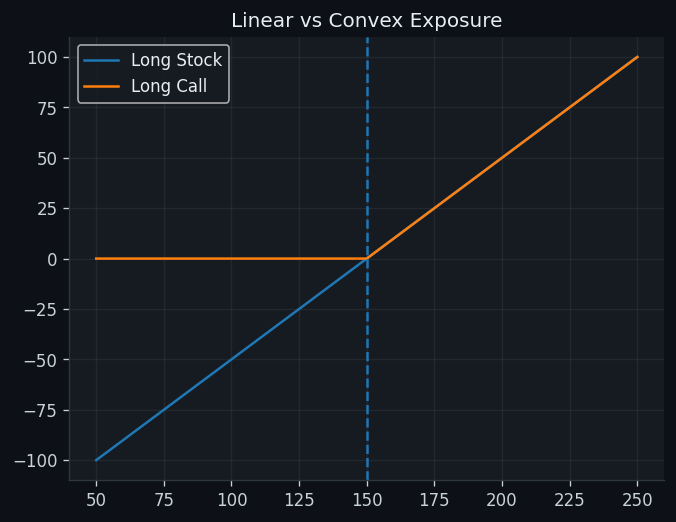

In [3]:
S = np.arange(50,251)

plt.plot(
    S,
    long_stock(S,150),
    label="Long Stock"
)

plt.plot(
    S,
    long_call(150,S),
    label="Long Call"
)

# plt.axhline(0, linestyle="--")
plt.axvline(150, linestyle="--")

plt.legend()
plt.grid(True)

plt.title("Linear vs Convex Exposure")

The stock participates in every outcome.

The call participates selectively.

Large downside moves stop mattering.

Large upside moves matter a lot.

The stock says:

I want exposure.

The call says:

I only want certain kinds of exposure.

That distinction sounds small.

It isn't.

At this point I stopped thinking of options as leveraged stocks.

They felt more like redesigned risk profiles.

-----

### Experiment 2: Where Does Optionality Actually Live?
Next I started moving the strike :

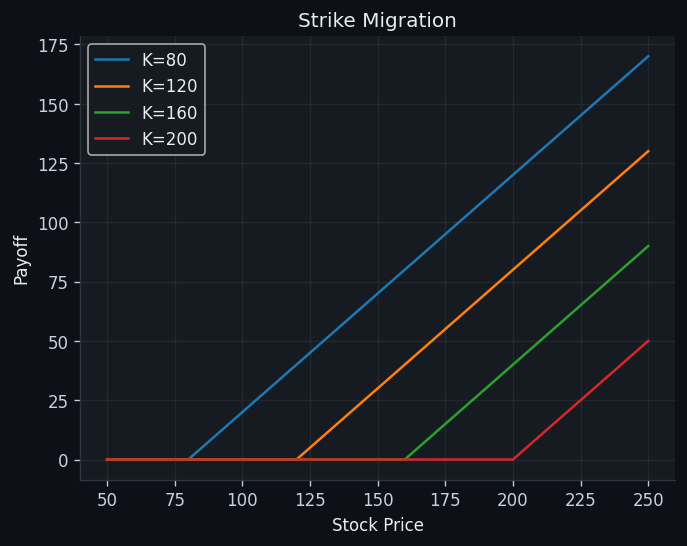

In [4]:
S = np.arange(50, 251)

for K in [80, 120, 160, 200]:
    plt.plot(
        S,
        long_call(K, S),
        label=f"K={K}"
    )

# plt.axhline(0, linestyle="--")
plt.xlabel("Stock Price")
plt.ylabel("Payoff")
plt.title("Strike Migration")
plt.legend()
plt.grid(True)

I expected different option contracts.

What I got instead was something stranger.

Most of the graph was dead.

The only interesting thing happening was near the strike.

The strike wasn't merely a parameter.

It was where the graph woke up.

I then looked at numerical slopes.

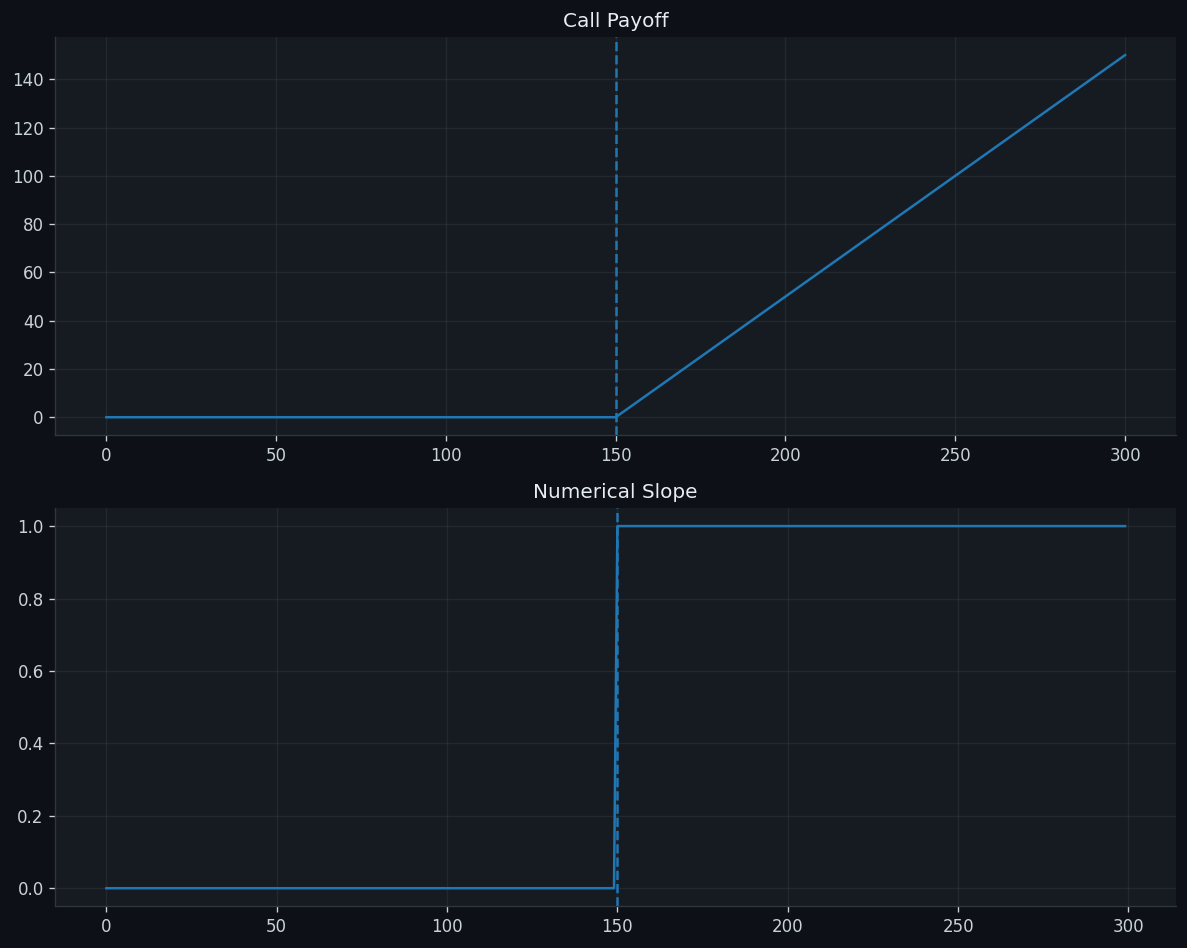

In [5]:
S = np.arange(0, 301)

K = 150

payoff = long_call(K, S)

slope = np.diff(payoff)

fig, ax = plt.subplots(
    2,
    1,
    figsize=(10,8)
)

ax[0].plot(S, payoff)

ax[0].axvline(
    K,
    linestyle="--"
)

ax[0].set_title(
    "Call Payoff"
)

ax[1].plot(
    S[:-1],
    slope
)

ax[1].axvline(
    K,
    linestyle="--"
)

ax[1].set_title(
    "Numerical Slope"
)

plt.tight_layout()

plt.show()

Same realization.

Most of the graph wasn't doing anything interesting.

All the action lived near uncertainty.

That led to the first genuinely useful mental model:

> Convexity doesn't live everywhere.

> Convexity lives where outcomes are uncertain.

The strike wasn't just a number.

It was the location where uncertainty became valuable

---

### Experiment 3: Being Right Isn't Enough

This one genuinely annoyed alot of people I suppose.

Suppose:

Strike = 150
Premium = 15

The stock finishes at:

151

I was right.

The stock went up.

The option still lost money.

I stared at that result for longer than I'd like to admit.

The direction was correct.

Reality agreed with me.

The market still took my money.

That's when I realized something fundamental:

Payoff and profitability are different objects.

The contract didn't change.

Only the premium changed.

Yet the economics changed completely.

The lesson wasn't:

Be right.

The lesson was:

Be more right than the price already expects.

That felt like the first real finance insight of the notebook

In [6]:
K = 150
premium = 15

terminal_prices = [151, 155, 160]

profits = [
    long_call_profit(K, S, premium)
    for S in terminal_prices
]

for S, profit in zip(terminal_prices, profits):

    print(
        f"Stock = {S:3} | Profit = {profit:6.2f}" )

Stock = 151 | Profit = -14.00
Stock = 155 | Profit = -10.00
Stock = 160 | Profit =  -5.00


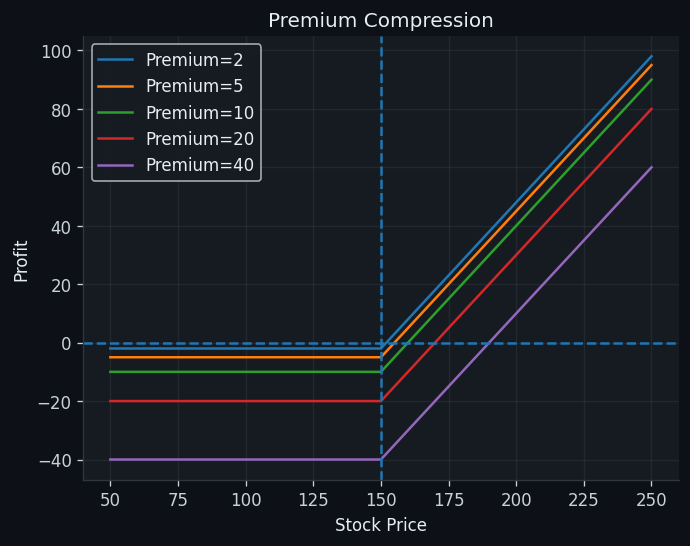

In [7]:
S = np.arange(50,251)

K = 150 # ------> Dashed blue Line

for premium in [2,5,10,20,40]:

    plt.plot(
        S,
        long_call_profit(K,S,premium),
        label=f"Premium={premium}"
    )

plt.axhline(0, linestyle="--")
plt.axvline(K, linestyle="--")

plt.title("Premium Compression")
plt.xlabel("Stock Price")
plt.ylabel("Profit")

plt.legend()
plt.grid(True)

---

### Experiment 4: The Insurance Company Problem

Then I plotted short put profits.

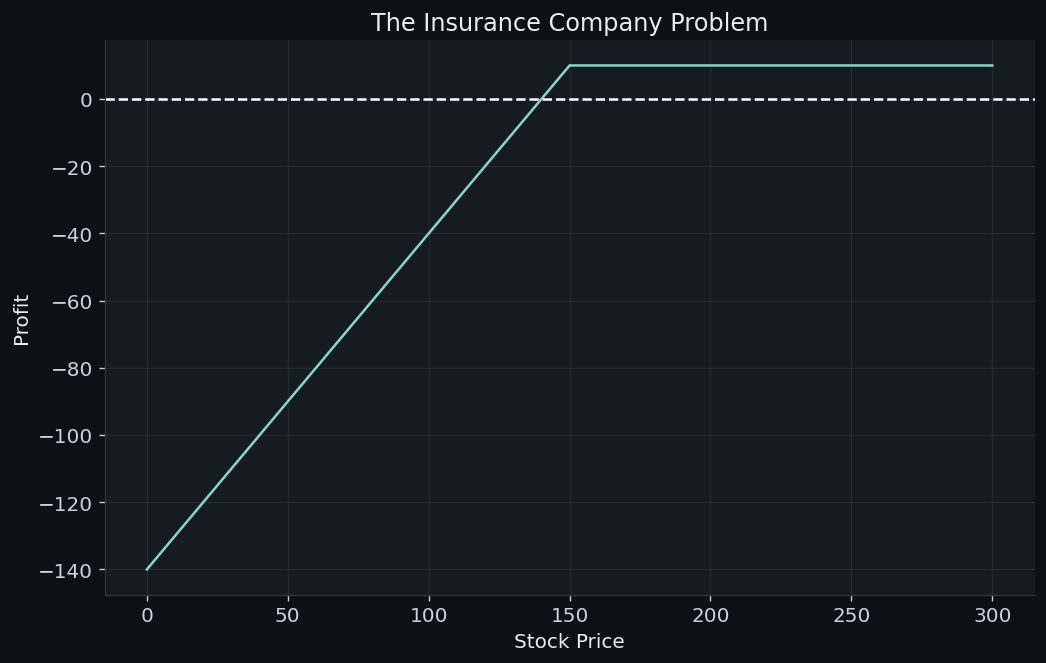

In [38]:
S = np.arange(0, 301)

K = 150
premium = 10

plt.figure(figsize=(10,6))

plt.plot(
    S,
    short_put_profit(
        K,
        S,
        premium
    )
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "The Insurance Company Problem"
)

plt.xlabel(
    "Stock Price"
)

plt.ylabel(
    "Profit"
)

plt.grid(True)

At first it looked beautiful.

Small gains.

Small gains.

Small gains.

Small gains.

Then a cliff.

The graph looked less like a trade and more like a business model.

Long periods of calm.

Predictable income.

Rare catastrophic losses.

I started seeing that shape everywhere.

Insurance
Warranties
Certain lending businesses
Some trading firms

The graph stopped looking like an option.

It started looking like risk itself.

One of the most interesting realizations wasn't about derivatives.

It was that many businesses are secretly payoff diagrams.

---


### Experiment 5: Venture Capital and Optionality
The long call graph created a different feeling.

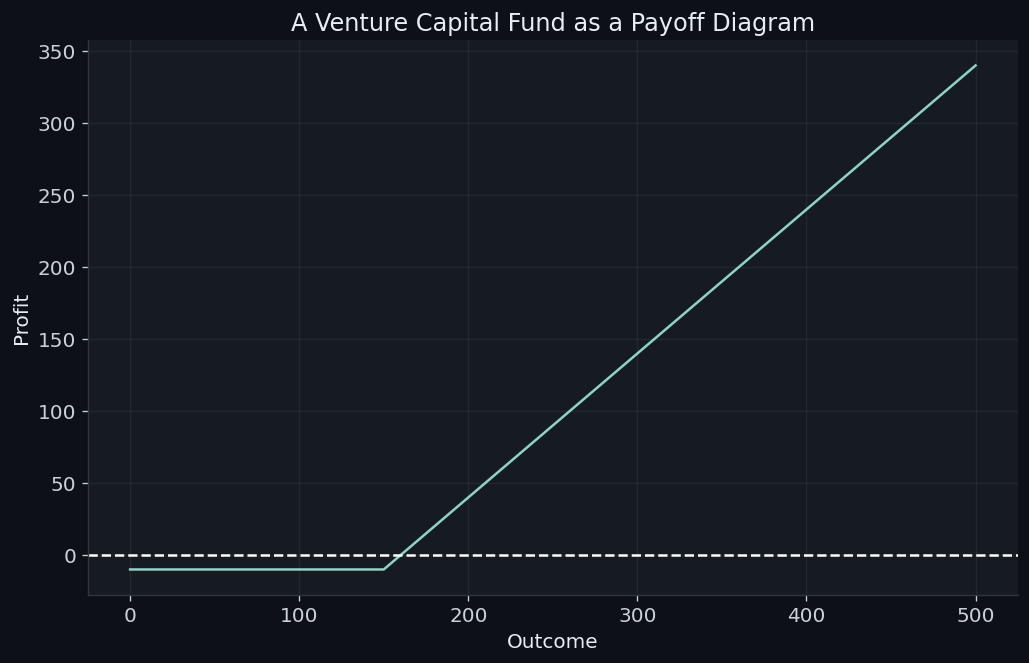

In [39]:
S = np.arange(0, 501)

K = 150
premium = 10

plt.figure(figsize=(10,6))

plt.plot(
    S,
    long_call_profit(
        K,
        S,
        premium
    )
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "A Venture Capital Fund as a Payoff Diagram"
)

plt.xlabel(
    "Outcome"
)

plt.ylabel(
    "Profit"
)

plt.grid(True)

plt.show()

Most outcomes lose money.

A few outcomes dominate everything.

Lose.
Lose.
Lose.
Lose.
Win so hard that nothing else matters.

The shape felt familiar.

Not because it looked like finance.

Because it looked like venture capital.

A startup portfolio doesn't need many winners.

It needs a few absurd winners.

The payoff structure of a long call and the return structure of venture investing suddenly felt related.

That was one of the first moments where optionality stopped feeling like a market concept.

It started feeling like a general framework for thinking about asymmetric outcomes.

---

### Experiment 6: Long Volatility vs Long Direction
The call demands a specific outcome.

The straddle only demands movement.

Direction becomes irrelevant.

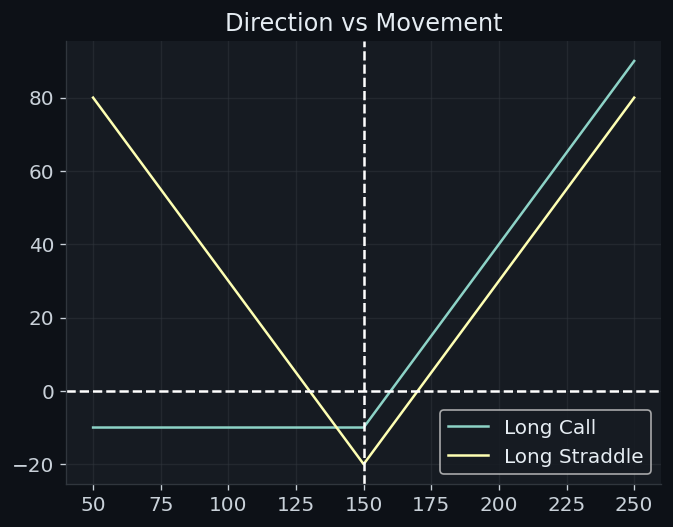

In [27]:
S = np.arange(50,251)

plt.plot(
    S,
    long_call_profit(150,S,10),
    label="Long Call"
)

plt.plot(
    S,
    long_straddle(
        150,
        S,
        10,
        10
    ),
    label="Long Straddle"
)

plt.axhline(0, linestyle="--")
plt.axvline(150, linestyle="--")

plt.legend()
plt.grid(True)

plt.title("Direction vs Movement")

plt.show()

This was the first time I felt that volatility itself could be treated as an asset.

The call is long direction.

The straddle is long surprise.

---

### Experiment 7: Selling Away Possibility

Then I built a bull spread.

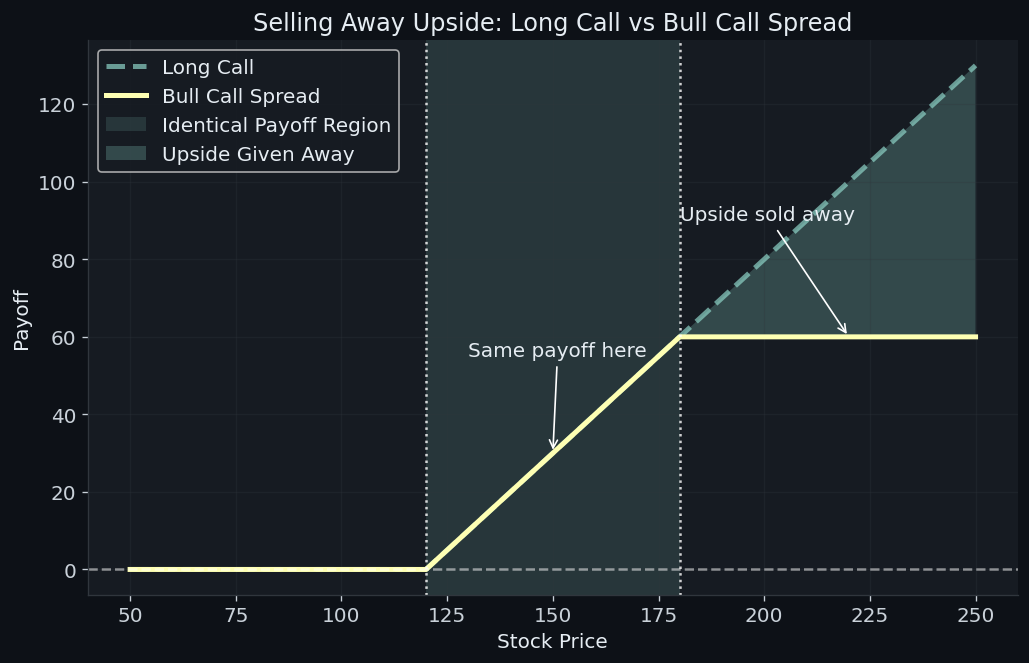

In [36]:
S = np.arange(50, 251)

# Payoffs
lc = long_call(120, S)
bcs = bull_call_spread(180, 120, S)

plt.figure(figsize=(10, 6))

# Long Call
plt.plot(
    S,
    lc,
    linestyle="--",
    linewidth=3,
    alpha=0.7,
    label="Long Call"
)

# Bull Call Spread
plt.plot(
    S,
    bcs,
    linewidth=3,
    label="Bull Call Spread"
)

# Highlight region where payoffs are identical
plt.axvspan(
    120,
    180,
    alpha=0.15,
    label="Identical Payoff Region"
)

# Highlight upside surrendered
plt.fill_between(
    S,
    bcs,
    lc,
    where=(lc > bcs),
    alpha=0.25,
    label="Upside Given Away"
)

# Annotate
plt.annotate(
    "Same payoff here",
    xy=(150, 30),
    xytext=(130, 55),
    arrowprops=dict(arrowstyle="->", color = "white")
)

plt.annotate(
    "Upside sold away",
    xy=(220, 60),
    xytext=(180, 90),
    arrowprops=dict(arrowstyle="->")
)

# Reference lines
plt.axvline(120, linestyle=":", alpha=0.8)
plt.axvline(180, linestyle=":", alpha=0.8)
plt.axhline(0, linestyle="--", alpha=0.5)

plt.title("Selling Away Upside: Long Call vs Bull Call Spread")
plt.xlabel("Stock Price")
plt.ylabel("Payoff")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

One additional option.

Completely different behavior.

The second option literally chopped off part of the future.

That was fascinating.

Not because the strategy worked.

Because it revealed what strategies really are.

Strategies aren't predictions.

Strategies are edited payoff diagrams.

You can literally reshape your future exposure by combining simple building blocks.

At that point options started feeling less like contracts and more like Lego.

---


### Experiment 8: Who Wants The Other Side?

I plotted:

Long Call Profit

vs

Short Call Profit

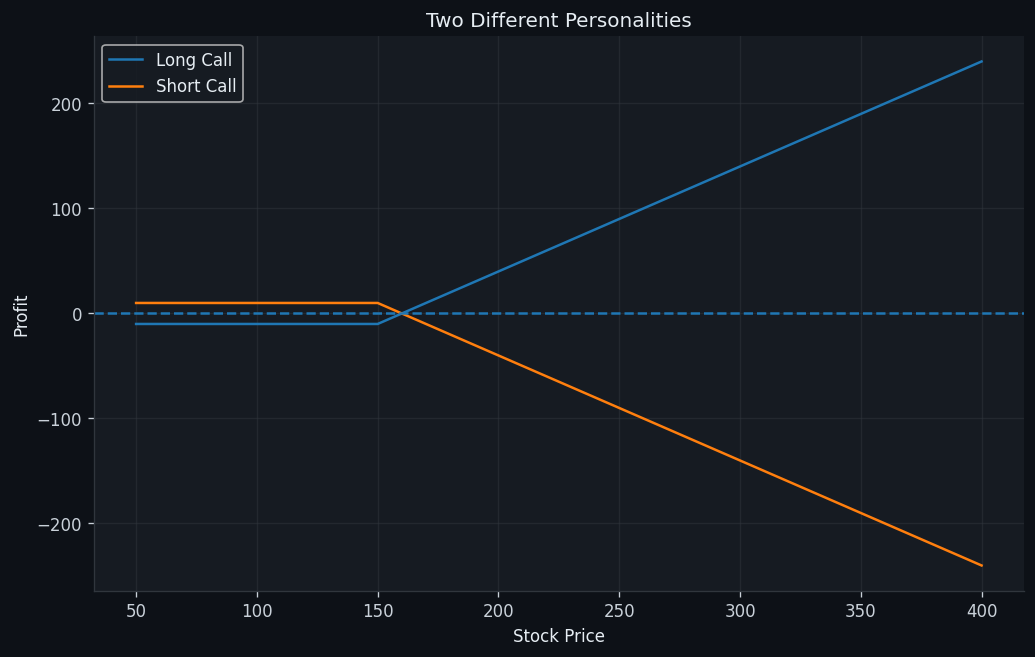

In [12]:
S = np.arange(50, 401)

K = 150
premium = 10

plt.figure(figsize=(10,6))

plt.plot(
    S,
    long_call_profit(
        K,
        S,
        premium
    ),
    label="Long Call"
)

plt.plot(
    S,
    short_call_profit(
        K,
        S,
        premium
    ),
    label="Short Call"
)

plt.axhline(0, linestyle="--")

plt.title(
    "Two Different Personalities"
)

plt.xlabel("Stock Price")
plt.ylabel("Profit")

plt.legend()
plt.grid(True)

plt.show()

Long Call

Many small losses
Rare huge wins

Short Call

Many small wins
Rare huge losses

Same contract.

Different experience.

Different psychology.

Different emotional journey.

This was the first time I appreciated why markets need both buyers and sellers of optionality.

They aren't disagreeing about the graph.

They're disagreeing about which risks they're willing to hold.

>> Optionality doesn't create tail risk.
>>It transfers tail risk.

---

### Experiment 9: The Plot That Changed Everything
This was the experiment that eventually pushed me toward pricing models.

I plotted:

Long Call

-

Short Put

against stock exposure.

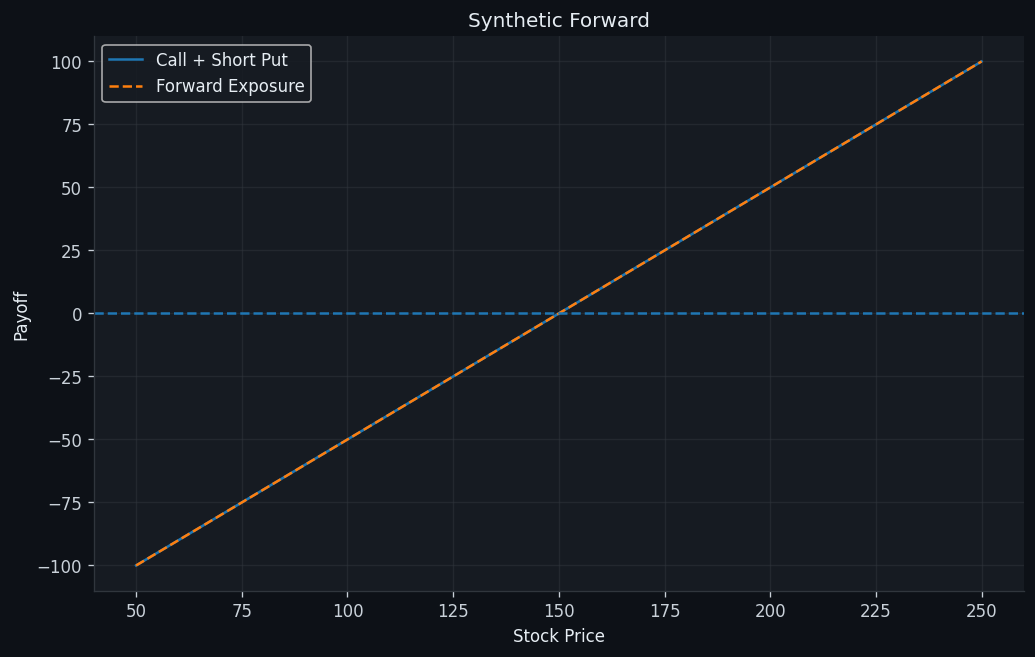

In [13]:
S = np.arange(50, 251)

K = 150

synthetic_stock = (
    long_call(K, S)
    +
    short_put(K, S)
)

plt.figure(figsize=(10,6))

plt.plot(
    S,
    synthetic_stock,
    label="Call + Short Put"
)

plt.plot(
    S,
    S - K,
    "--",
    label="Forward Exposure"
)

plt.axhline(0, linestyle="--")

plt.title(
    "Synthetic Forward"
)

plt.xlabel("Stock Price")
plt.ylabel("Payoff")

plt.legend()
plt.grid(True)

I expected something similar.

I got something identical.

The curves overlapped perfectly.

That bothered me.

A lot.

I thought contracts were fundamental.

Apparently they weren't.

Exposure was fundamental.

Different instruments.

Same exposure.

Which immediately pointed to the question posed in every book....

If two portfolios create the same future cash flows...

shouldn't they have the same value?

That question turned out to be far more important than any payoff diagram.

----

### What This Notebook Failed To Explain

By the end of these experiments, I understood exposure much better.

I understood:

- Asymmetry
- Convexity
- Risk transfer
- Optionality
- Replication

But something was missing.

The diagrams explained what I owned.

They did not explain what it was worth.

Two questions remained:

- Why does a call have a particular premium?
- Why can't arbitrage exploit equivalent exposures?

Those questions forced me beyond payoff geometry.

The next step wasn't another strategy.

It was pricing.

And that journey begins with a binomial tree... 